## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import os 
import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/') # change to your ultrasonicTesting directory
from tqdm import tqdm

import numpy as np
import pandas as pd
import pywt


from matplotlib import pyplot as plt
from scipy.signal import butter, sosfiltfilt

import tomography as tm
import pickleJar as pj

In [3]:
# w front wall
# sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_back_pulseecho_150_32mm_1mm_0_02_voltrange.sqlite3'

# wo front wall
sqlite_file = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.sqlite3'

dir, filename = os.path.split(sqlite_file)
pj.sqliteToPickle(sqlite_file)

pickle_file = sqlite_file.replace('.sqlite3', '.pickle')
pickle_data = pj.loadPickle(pickle_file)

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Group/Data/Ultrasound/General Motors/Prismatic Data/08172026_jellyroll_front_pulseecho_150_32mm_1mm_0_02_voltrange_changedtimetime1786999468.pickle already exists. Conversion aborted.


In [4]:
# convert to pandas datafram for easier access
waveform_df = pd.DataFrame({k:v for k,v in pickle_data.items() if isinstance(k, int)}).transpose() 

## get info about sampling freq, etc

In [5]:
dt = (pickle_data[0]['time'][1] - pickle_data[0]['time'][0]) * 1e-9
omega_scaled = pickle_data['parameters']['transducerFrequency'] * 1e6 * dt
samples = pickle_data['parameters']['samples']
waves = pickle_data['parameters']['waves']
fs = 1/dt

# butterworth filter
# sos = butter(3, fs/250, btype = 'highpass', analog = False, fs = fs, output = 'sos')
# sos = butter(3, fs/10, btype = 'lowpass', analog = False, fs = fs, output = 'sos')
# you can change the wn = [high, low] passband if you know feature size
sos = butter(3, [fs/250,fs/5], btype = 'bandpass', analog = False, fs = fs, output = 'sos') 
refGain = pickle_data['parameters']['gainForward'] / 10 # dont need unless gain is changing

def ungain_filter(x):
    '''function to ungain and filter a signal'''
    # change signal to pre-amplification voltage
    # x_ungained = pj.correctVoltageByGain(x, refGain) # don't need unless gain is changing
    # apply butterworth filter forward and reverse to pre-amplified signal
    x_filtered = sosfiltfilt(sos, x)
    return x_filtered

## preprocess (filter)

In [79]:
# preprocess 
waveform_df['voltage_preprocessed'] = waveform_df['voltage'].apply(ungain_filter)

In [80]:
# i = 3000

# plt.plot(waveform_df['time'][i], waveform_df['voltage_preprocessed'][i], label = 'bandpass filtering')
# plt.plot(waveform_df['time'][i], waveform_df['voltage'][i]-waveform_df['voltage'][i].min(), label = 'no bandpass filtering (min subtraction)')
# plt.legend()

In [81]:

# pywt's complex Morlet is parameterized as 'cmorB-C'
# B = bandwidth parameter, C = center frequency (normalized, dimensionless)
# For matching a known pulse center frequency, C=1.0 with B~1.0-2.0 works well;
# increase B for better frequency resolution (worse time resolution)
# TODO: we need to figure out what the pulse width of compact puler is. it is fixed by transducer frequency i think

wavelet = 'cmor0.5-1.0' # we can make B a little smaller since we dont care ab frequency as much # TODO: test several B to whatever matches water pulse the best

freqs_of_interest = np.linspace(100e3, 4e6, 100)   # 100kHz-4 MHz. You can change the nmber of freq calculations to do. Takes a lot of memory tho
central_freq = pywt.central_frequency(wavelet)      # normalized center freq of the wavelet
scales = central_freq * fs / freqs_of_interest      # scale = f_c * fs / f_target
freqs_hz = pywt.scale2frequency(wavelet, scales) * fs

## calculate cwt

In [99]:
# gets wavelet transforms. slow af and takes a lot of memory
# maybe u wanna save the new dataframe as a csv or pickle and not run this every time

def get_cwt(row):
    coeffs, _ = pywt.cwt(row['voltage_preprocessed'], scales, wavelet, sampling_period=dt)
    return coeffs

tqdm.pandas()
waveform_df['morlet_cwt'] = waveform_df.progress_apply(get_cwt, axis=1)

100%|██████████| 4983/4983 [02:31<00:00, 32.98it/s]


In [100]:
# get_magnitudes of the wavelet transforms
def cwt_magnitude(row):
    return np.abs(row['morlet_cwt'])

tqdm.pandas()
waveform_df['morlet_cwt_magnitude'] = waveform_df.progress_apply(cwt_magnitude, axis=1)

  0%|          | 0/4983 [00:00<?, ?it/s]

  0%|          | 8/4983 [00:00<01:05, 75.71it/s]Traceback (most recent call last):
  File "/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/IPython/core/completer.py", line 3674, in _complete
    result = matcher(context)
  File "/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/IPython/core/completer.py", line 2384, in magic_matcher
    global_matches = self.global_matches(bare_text)
  File "/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/IPython/core/completer.py", line 1169, in global_matches
    for word in lst:
                ^^^
RuntimeError: dictionary changed size during iteration
100%|██████████| 4983/4983 [00:56<00:00, 88.25it/s] 


/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_46007/206230414.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


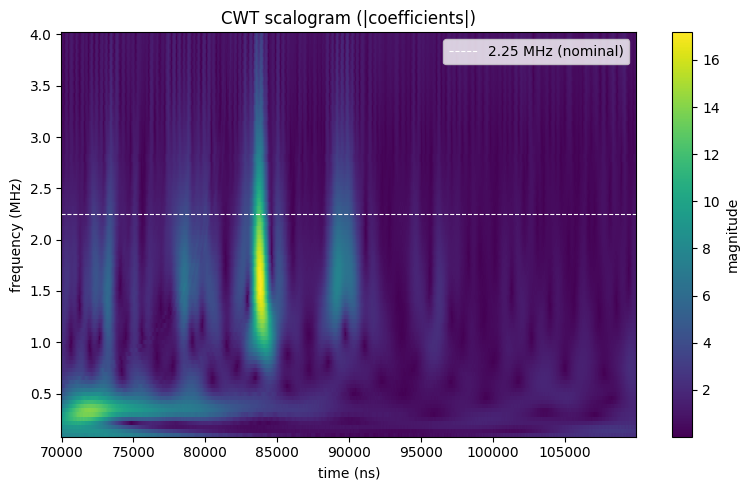

In [101]:
# visualize cwt. streakiness is caused by the spacing at the frequency being larger

i=3000

plt.figure(figsize=(8, 5))
plt.pcolormesh(waveform_df.loc[i]['time'], 
               freqs_hz / 1e6, 
               waveform_df.loc[i]['morlet_cwt_magnitude'], 
               shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (|coefficients|)')
plt.colorbar(label='magnitude')
plt.legend()
plt.tight_layout()
plt.show()

## find peaks within a band range

In [102]:
from scipy.signal import find_peaks

# find the CWT coefficients within 5% of 2.25 MHz
freq_center = 2.25e6
band_frac = 0.05
band_mask = (freqs_hz >= freq_center * (1 - band_frac)) & (freqs_hz <= freq_center * (1 + band_frac))
freq_window = freqs_hz[band_mask]

In [103]:
def get_badpass_profile(row):
    '''get peak location of max value in the frequency band of interest'''
    return np.max(row['morlet_cwt_magnitude'][band_mask], 
                         axis=0)
    
tqdm.pandas()
waveform_df['morlet_bandpass_profile'] = waveform_df.progress_apply(get_badpass_profile, axis=1)

100%|██████████| 4983/4983 [00:02<00:00, 1895.68it/s]


In [104]:
def get_peak_times(row):
    peaks, properties = find_peaks(
        row['morlet_bandpass_profile'],
        prominence=0.1 * row['morlet_bandpass_profile'].max()
    )

    return peaks

tqdm.pandas()
waveform_df['morlet_cwt_peak_inds'] = waveform_df.progress_apply(get_peak_times, axis=1)

  0%|          | 0/4983 [00:00<?, ?it/s]

100%|██████████| 4983/4983 [00:00<00:00, 13474.67it/s]


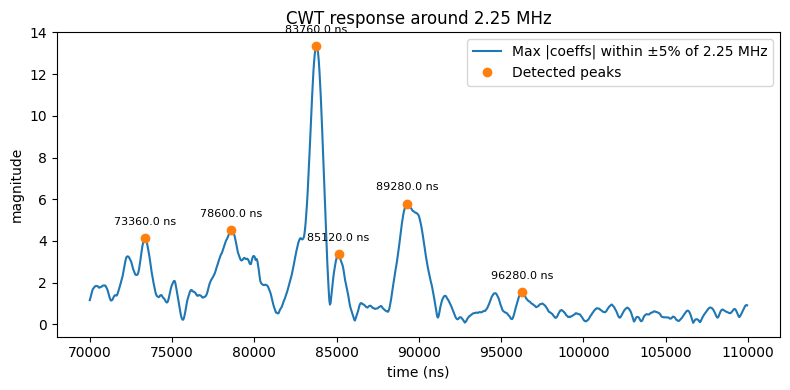

In [105]:

# visualize cwt bandpass profile and peaks
i=3000

peak_inds = waveform_df.loc[i]['morlet_cwt_peak_inds']

plt.figure(figsize=(8, 4))
plt.plot(waveform_df.loc[i]['time'], 
         waveform_df.loc[i]['morlet_bandpass_profile'], 
         label=f'Max |coeffs| within ±{band_frac * 100:.0f}% of {freq_center / 1e6:.2f} MHz')

plt.plot(waveform_df.loc[i]['time'][peak_inds], 
         waveform_df.loc[i]['morlet_bandpass_profile'][peak_inds], 
         'o', label='Detected peaks')

for x, y in zip(waveform_df.loc[i]['time'][peak_inds], waveform_df.loc[i]['morlet_bandpass_profile'][peak_inds]):
    plt.annotate(
        f'{x:.1f} ns',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

plt.xlabel('time (ns)')
plt.ylabel('magnitude')
plt.title('CWT response around 2.25 MHz')
plt.legend()
plt.tight_layout()
plt.show()

I'm still figuring out exactly what the phase and group delay mean in a cwt so maybe you don't have to include this...

## look at phase and group delay of cwt coeffs

In [106]:
def get_phase(row): 
    return np.unwrap(np.angle(row['morlet_cwt']))

tqdm.pandas()
waveform_df['morlet_cwt_phase'] = waveform_df.progress_apply(get_phase, axis=1)

100%|██████████| 4983/4983 [01:25<00:00, 58.37it/s] 


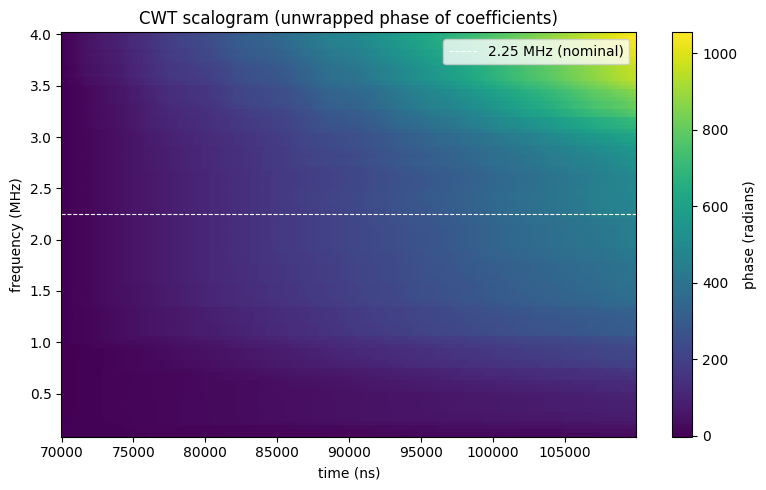

In [107]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(waveform_df.loc[i]['time'], 
               freqs_hz / 1e6, 
               waveform_df.loc[i]['morlet_cwt_phase'],
               shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT scalogram (unwrapped phase of coefficients)')
plt.colorbar(label='phase (radians)')
plt.legend()
plt.tight_layout()
plt.show()

In [108]:
def get_group_delay(row):
    return -np.gradient(row['morlet_cwt_phase'], axis=1) / (2 * np.pi * freqs_hz[:, np.newaxis]) * 1e9 
    # convert to ns

tqdm.pandas()
waveform_df['morlet_cwt_group_delay'] = waveform_df.progress_apply(get_group_delay, axis=1)

100%|██████████| 4983/4983 [00:31<00:00, 159.45it/s]


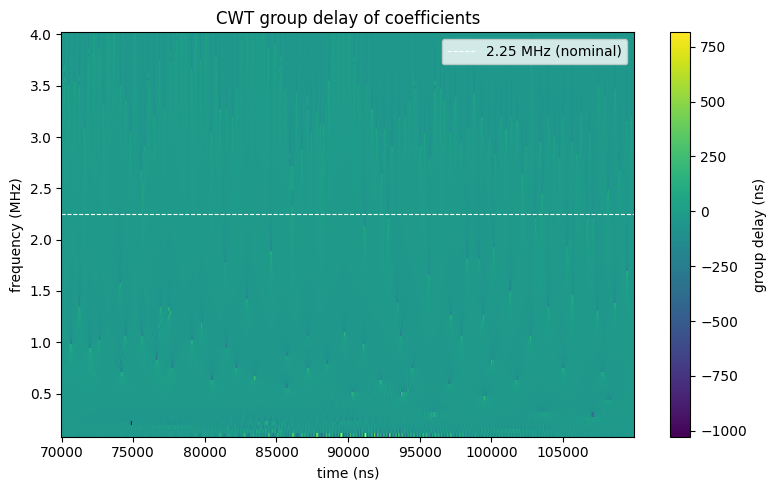

In [109]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(waveform_df.loc[i]['time'], 
               freqs_hz / 1e6, 
               waveform_df.loc[i]['morlet_cwt_group_delay'], 
               shading='auto', cmap='viridis')
plt.axhline(2.25, color='w', linestyle='--', linewidth=0.8, label='2.25 MHz (nominal)')
plt.xlabel('time (ns)')
plt.ylabel('frequency (MHz)')
plt.title('CWT group delay of coefficients')
plt.colorbar(label='group delay (ns)')
plt.legend()
plt.tight_layout()
plt.show()

## compare morlet with water mother wavelet

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Wavelet Function (psi) cmor0.5-1.0')

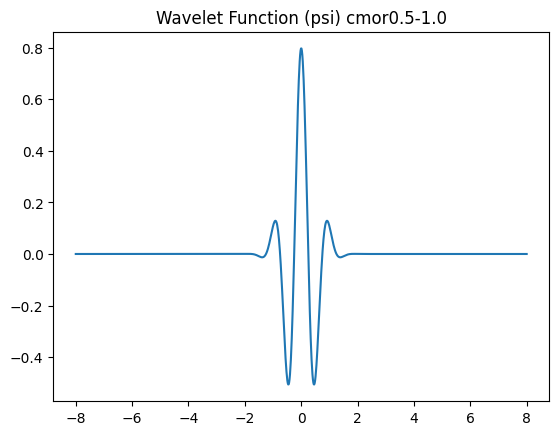

In [110]:
# Bad mother?
w = pywt.ContinuousWavelet(wavelet)
psi, x = w.wavefun(level=10)
plt.plot(x, psi)
plt.title("Wavelet Function (psi) " + wavelet)


In [111]:
import sqliteUtils as squ

# open water file from sam's ondrive folder. replace w your won path
sqlite_water = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Sam Amsterdam/acoustic scan data/tomography_testing/example_data/SA_tomography_test_water.sqlite3'

con,cur = squ.openDB(sqlite_water)
parameters = squ.retrieveParameters(cur, 'parameters')
time = squ.fetchData(cur, 'time', 'acoustics')[0]
voltage = squ.fetchData(cur, 'voltage_transmission_forward', 'acoustics')

freq_params_dict = {
    'dt': (time[1] - time[0]) * 1e-9, 
    'omega_scaled': parameters['transducerFrequency'] * 1e6 * (time[1] - time[0]) * 1e-9, 
    'samples': parameters['samples'], 
    'waves': parameters['waves'], 
    'fs': 1 / (time[1] - time[0]) * 1e-9
    }

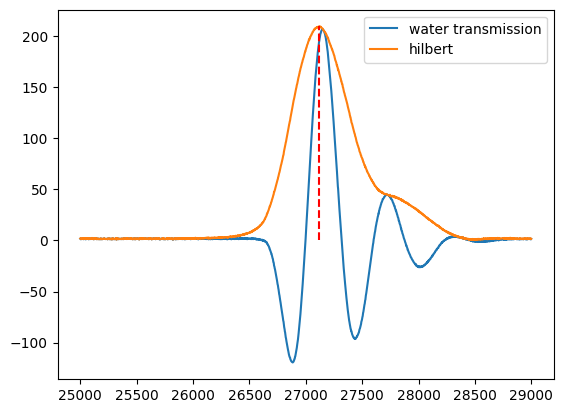

In [112]:
# look at signal in water. p clean so we don't have to apply filter
from scipy.signal import hilbert, find_peaks

analytic_signal = hilbert(voltage[0,:2000])
peaks, _ = find_peaks(abs(analytic_signal), prominence=200)  # Adjust the height parameter as needed
plt.plot(time[:2000], voltage[0,:2000], label='water transmission')
plt.plot(time[:2000], abs(analytic_signal), label='hilbert')
plt.vlines(time[:2000][peaks], ymin=0, ymax=abs(analytic_signal)[peaks], color='r', linestyle='--')
plt.legend()
peak_time = time[:2000][peaks]

In [113]:
# interpolate to prismatic time scale
from scipy.interpolate import interp1d

use_time = waveform_df['time'][i]
use_data = waveform_df['voltage_preprocessed'][i]

t_for_interp = time[:2000]-peak_time[0] # center time around 0 for xcorrelation
interp_func = interp1d(t_for_interp, voltage[0,:2000], kind='linear', fill_value='extrapolate')
new_t = np.arange(t_for_interp[0], t_for_interp[-1], dt*1e9) # time scale in prismatic cell
mother_wavelet_interp = interp_func(np.arange(t_for_interp[0], t_for_interp[-1], dt*1e9)) # interp for prosmatic time scale
mother_scaled = mother_wavelet_interp/abs(mother_wavelet_interp).max()*abs(use_data).max()


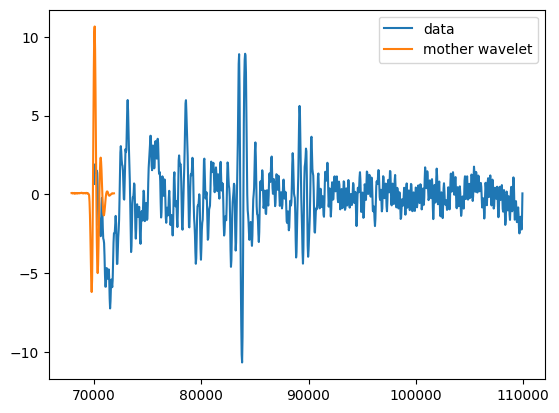

In [114]:
# look at your new mother
plt.plot(use_time, use_data, label = 'data')
plt.plot(new_t+use_time[0], mother_scaled, label = 'mother wavelet')
plt.legend()

## x correlation with water as mother wavelet

In [115]:
from scipy.signal import correlate

def correlate_water(row):
    use_time = row['time']
    use_data = row['voltage_preprocessed']
    xcorr = correlate(use_data, mother_scaled, mode='same')
    xcorr_scaled = xcorr/abs(xcorr).max()*abs(use_data).max()
    return xcorr_scaled

tqdm.pandas()
waveform_df['water_xcorr'] = waveform_df.progress_apply(correlate_water, axis=1)

  2%|▏         | 96/4983 [00:00<00:05, 929.95it/s]

100%|██████████| 4983/4983 [00:01<00:00, 3615.90it/s]


In [116]:
def apply_abs_hilbert(row):
    return abs(hilbert(row['water_xcorr']))

tqdm.pandas()
waveform_df['water_xcorr_hilbert'] = waveform_df.progress_apply(apply_abs_hilbert, axis=1)

  0%|          | 0/4983 [00:00<?, ?it/s]

100%|██████████| 4983/4983 [00:00<00:00, 8919.51it/s] 


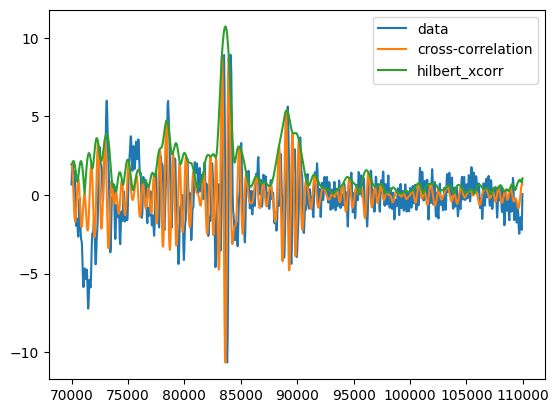

In [117]:
i=3000

plt.plot(waveform_df['time'][i], waveform_df['voltage_preprocessed'][i], label = 'data')
plt.plot(waveform_df['time'][i], waveform_df['water_xcorr'][i], label = 'cross-correlation')
plt.plot(waveform_df['time'][i], waveform_df['water_xcorr_hilbert'][i], label = 'hilbert_xcorr')
plt.legend()

## Peaks of xcorr

In [118]:
def get_xcorr_peak_times(row):
    peaks, properties = find_peaks(
        row['water_xcorr_hilbert'],
        prominence=0.1 * row['water_xcorr_hilbert'].max()
    )
    return peaks

tqdm.pandas()
waveform_df['water_xcorr_peak_inds'] = waveform_df.progress_apply(get_xcorr_peak_times, axis=1)

  0%|          | 0/4983 [00:00<?, ?it/s]

100%|██████████| 4983/4983 [00:00<00:00, 8586.44it/s] 


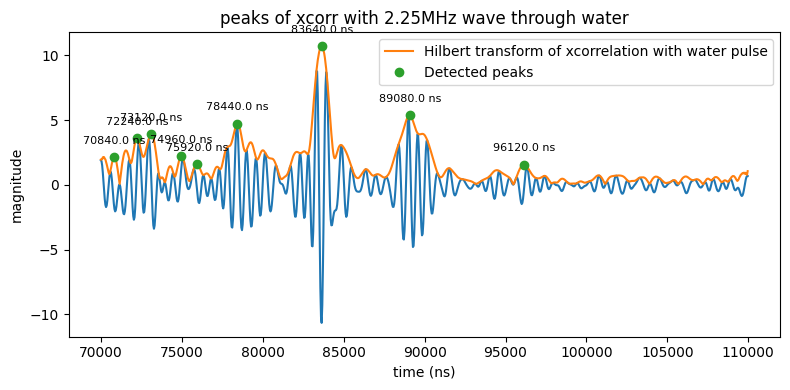

In [120]:
# visualize 
i=3000

peak_inds = waveform_df.loc[i]['water_xcorr_peak_inds']

plt.figure(figsize=(8, 4))
plt.plot(waveform_df.loc[i]['time'], 
         waveform_df.loc[i]['water_xcorr'], )

plt.plot(waveform_df.loc[i]['time'], 
         waveform_df.loc[i]['water_xcorr_hilbert'], 
         label=f'Hilbert transform of xcorrelation with water pulse')

plt.plot(waveform_df.loc[i]['time'][peak_inds], 
         waveform_df.loc[i]['water_xcorr_hilbert'][peak_inds], 
         'o', label='Detected peaks')

for x, y in zip(waveform_df.loc[i]['time'][peak_inds], 
                waveform_df.loc[i]['water_xcorr_hilbert'][peak_inds]
                ):
    plt.annotate(
        f'{x:.1f} ns',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

plt.xlabel('time (ns)')
plt.ylabel('magnitude')
plt.title('peaks of xcorr with 2.25MHz wave through water')
plt.legend()
plt.tight_layout()
plt.show()